<a href="https://colab.research.google.com/github/Bhuvana908/ML-Projects/blob/main/Lung%20Cancer%20Classification%20using%20VGG16%20%26%20ResNet50/Lung_Cancer_Classification_using_VGG16_%26_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
import json
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models as torch_models

print("All libraries imported!")
print(f"TensorFlow : {tf.__version__}")
print(f"PyTorch    : {torch.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

✅ All libraries imported!
TensorFlow : 2.19.0
PyTorch    : 2.10.0+cu128
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import os, json

kaggle_creds = {
    "username": "kadasanibhuvanareddy",
    "key": "59c6d404963a85e0b03f0e972e7d0e4b"
}

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)

with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print("kaggle.json created!")

!kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images


!ls -lh *.zip


from zipfile import ZipFile
with ZipFile('lung-and-colon-cancer-histopathological-images.zip', 'r') as z:
    z.extractall('/content/lc25000')
    print("✅ Extracted successfully!")


import os
for item in os.listdir('/content/lc25000'):
    print(item)

✅ kaggle.json created!
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
lung-and-colon-cancer-histopathological-images.zip: Skipping, found more recently modified local copy (use --force to force download)
-rw-r--r-- 1 root root 1.8G Apr 14  2020 lung-and-colon-cancer-histopathological-images.zip
✅ Extracted successfully!
lung_colon_image_set


In [8]:
SOURCE_DIR   = '/content/lc25000/lung_colon_image_set/lung_image_sets'
LUNG_CLASSES = ['lung_aca', 'lung_n', 'lung_scc']

print("Lung Classes Found:")
for cls in LUNG_CLASSES:
    path  = os.path.join(SOURCE_DIR, cls)
    count = len(os.listdir(path))
    print(f"   {cls}: {count} images")

✅ Lung Classes Found:
   lung_aca: 5000 images
   lung_n: 5000 images
   lung_scc: 5000 images


In [9]:
!pip install split-folders -q
import splitfolders

splitfolders.ratio(
    SOURCE_DIR,
    output="/content/lung_data",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)


for split in ['train', 'val', 'test']:
    for cls in ['colon_aca', 'colon_n']:
        path = f'/content/lung_data/{split}/{cls}'
        if os.path.exists(path):
            shutil.rmtree(path)
            print(f"🗑️ Removed: {cls} from {split}")


print("\n✅ Final Dataset Split:")
for split in ['train', 'val', 'test']:
    print(f"\n  📂 {split}:")
    for cls in sorted(os.listdir(f'/content/lung_data/{split}')):
        count = len(os.listdir(f'/content/lung_data/{split}/{cls}'))
        print(f"      {cls}: {count} images")

Copying files: 15000 files [00:03, 4294.01 files/s]


✅ Final Dataset Split:

  📂 train:
      lung_aca: 3500 images
      lung_n: 3500 images
      lung_scc: 3500 images

  📂 val:
      lung_aca: 750 images
      lung_n: 750 images
      lung_scc: 750 images

  📂 test:
      lung_aca: 750 images
      lung_n: 750 images
      lung_scc: 750 images


Classes: ['lung_aca', 'lung_n', 'lung_scc']


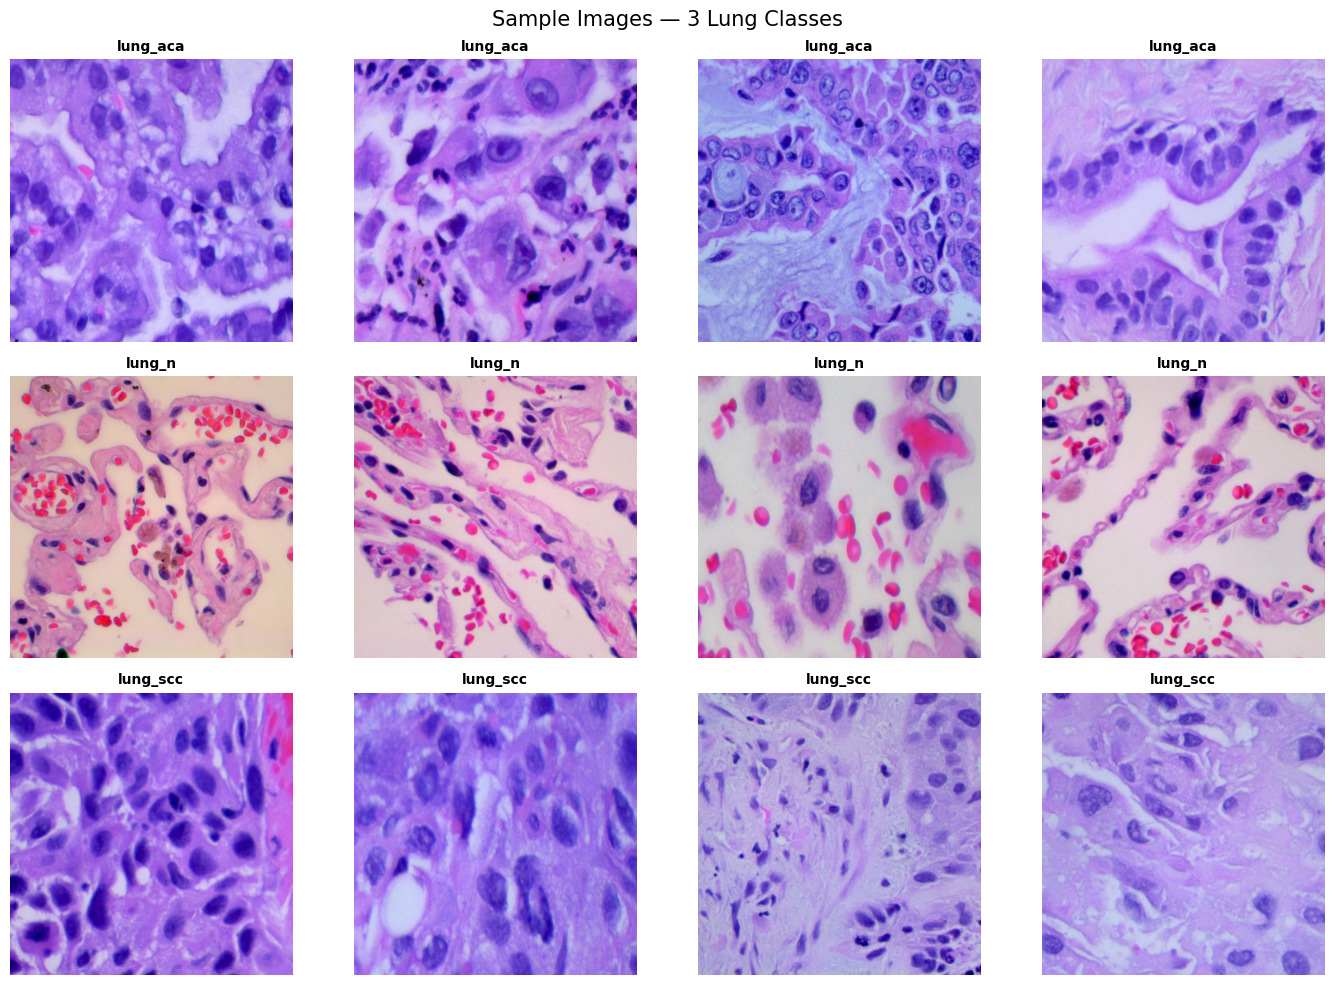

In [10]:
TRAIN_DIR   = '/content/lung_data/train'
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASS_NAMES)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for i, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs     = random.sample(os.listdir(cls_path), 4)
    for j, img_name in enumerate(imgs):
        img = Image.open(os.path.join(cls_path, img_name))
        axes[i][j].imshow(img)
        axes[i][j].set_title(cls, fontsize=10, fontweight='bold')
        axes[i][j].axis('off')

plt.suptitle("Sample Images — 3 Lung Classes", fontsize=15)
plt.tight_layout()
plt.show()

# Using TensorFlow

In [11]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 3

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    '/content/lung_data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
val_gen = val_test_datagen.flow_from_directory(
    '/content/lung_data/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
test_gen = val_test_datagen.flow_from_directory(
    '/content/lung_data/test',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Data Generators Ready!")
print(f"   Train  : {train_gen.samples} images")
print(f"   Val    : {val_gen.samples} images")
print(f"   Test   : {test_gen.samples} images")
print(f"   Classes: {train_gen.class_indices}")

Found 10500 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
Found 2250 images belonging to 3 classes.
✅ Data Generators Ready!
   Train  : 10500 images
   Val    : 2250 images
   Test   : 2250 images
   Classes: {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}


In [12]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False

tf_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

tf_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tf_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,811 (56.64 MB)

 Trainable params: 132,611 (518.01 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/tf_lung_vgg16.h5',
        save_best_only=True, verbose=1
    )
]

print("Training TensorFlow VGG16...")
tf_history = tf_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)
print("TensorFlow Training Complete!")

🚀 Training TensorFlow VGG16...
Epoch 1/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step - accuracy: 0.7293 - loss: 0.6301
Epoch 1: val_loss improved from inf to 0.28279, saving model to /content/drive/MyDrive/tf_lung_vgg16.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 193s 542ms/step - accuracy: 0.7296 - loss: 0.6294 - val_accuracy: 0.9493 - val_loss: 0.2828 - learning_rate: 1.0000e-04
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9068 - loss: 0.2437
Epoch 2: val_loss improved from 0.28279 to 0.15366, saving model to /content/drive/MyDrive/tf_lung_vgg16.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 515ms/step - accuracy: 0.9068 - loss: 0.2437 - val_accuracy: 0.9489 - val_loss: 0.1537 - learning_rate: 1.0000e-04
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.9197 - loss: 0.2076
Epoch 3: val_loss improved from 0.15366 to 0.12336, saving model to /content/drive/MyDrive/tf_lung_vgg16.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 174s 530ms/step - accuracy: 0.9197 - loss: 0.2076 - val_accuracy: 0.9516 - val_loss: 0.1234 - learning_rate: 1.0000e-04
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9296 - loss: 0.1871
Epoch 4: val_loss improved from 0.12336 to 0.11624, saving model to /content/drive/MyDrive/tf_lung_vgg16.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 171s 518ms/step - accuracy: 0.9296 - loss: 0.1871 - val_accuracy: 0.9560 - val_loss: 0.1162 - learning_rate: 1.0000e-04
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.9360 - loss: 0.1739
Epoch 5: val_loss improved from 0.11624 to 0.09972, saving model to /content/drive/MyDrive/tf_lung_vgg16.h5


...

329/329 ━━━━━━━━━━━━━━━━━━━━ 181s 549ms/step - accuracy: 0.9419 - loss: 0.1398 - val_accuracy: 0.9711 - val_loss: 0.0808 - learning_rate: 1.0000e-04
Epoch 12/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.9483 - loss: 0.1384
Epoch 12: val_loss did not improve from 0.08076
329/329 ━━━━━━━━━━━━━━━━━━━━ 171s 518ms/step - accuracy: 0.9483 - loss: 0.1384 - val_accuracy: 0.9653 - val_loss: 0.0898 - learning_rate: 1.0000e-04
Epoch 13/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step - accuracy: 0.9464 - loss: 0.1355
Epoch 13: val_loss improved from 0.08076 to 0.07701, saving model to /content/drive/MyDrive/tf_lung_vgg16.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 169s 514ms/step - accuracy: 0.9464 - loss: 0.1355 - val_accuracy: 0.9720 - val_loss: 0.0770 - learning_rate: 1.0000e-04
Epoch 14/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.9508 - loss: 0.1291
Epoch 14: val_loss did not improve from 0.07701
329/329 ━━━━━━━━━━━━━━━━━━━━ 174s 530ms/step - accuracy: 0.9508 - loss: 0.1291 - val_accuracy: 0.9671 - val_loss: 0.0868 - learning_rate: 1.0000e-04
Epoch 15/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.9508 - loss: 0.1240
Epoch 15: val_loss improved from 0.07701 to 0.07308, saving model to /content/drive/MyDrive/tf_lung_vgg16.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 174s 529ms/step - accuracy: 0.9508 - loss: 0.1240 - val_accuracy: 0.9729 - val_loss: 0.0731 - learning_rate: 1.0000e-04
Epoch 16/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9529 - loss: 0.1184
Epoch 16: val_loss did not improve from 0.07308
329/329 ━━━━━━━━━━━━━━━━━━━━ 168s 511ms/step - accuracy: 0.9529 - loss: 0.1184 - val_accuracy: 0.9689 - val_loss: 0.0782 - learning_rate: 1.0000e-04
Epoch 17/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9535 - loss: 0.1195
Epoch 17: val_loss improved from 0.07308 to 0.07173, saving model to /content/drive/MyDrive/tf_lung_vgg16.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 516ms/step - accuracy: 0.9535 - loss: 0.1195 - val_accuracy: 0.9724 - val_loss: 0.0717 - learning_rate: 1.0000e-04
Epoch 18/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.9467 - loss: 0.1276
Epoch 18: val_loss improved from 0.07173 to 0.07080, saving model to /content/drive/MyDrive/tf_lung_vgg16.h5


329/329 ━━━━━━━━━━━━━━━━━━━━ 170s 517ms/step - accuracy: 0.9467 - loss: 0.1276 - val_accuracy: 0.9711 - val_loss: 0.0708 - learning_rate: 1.0000e-04
Epoch 19/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.9645 - loss: 0.1044
Epoch 19: val_loss did not improve from 0.07080
329/329 ━━━━━━━━━━━━━━━━━━━━ 171s 520ms/step - accuracy: 0.9645 - loss: 0.1044 - val_accuracy: 0.9724 - val_loss: 0.0717 - learning_rate: 1.0000e-04
Epoch 20/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9546 - loss: 0.1143
Epoch 20: val_loss did not improve from 0.07080
329/329 ━━━━━━━━━━━━━━━━━━━━ 168s 510ms/step - accuracy: 0.9546 - loss: 0.1143 - val_accuracy: 0.9627 - val_loss: 0.0849 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 18.
✅ TensorFlow Training Complete!


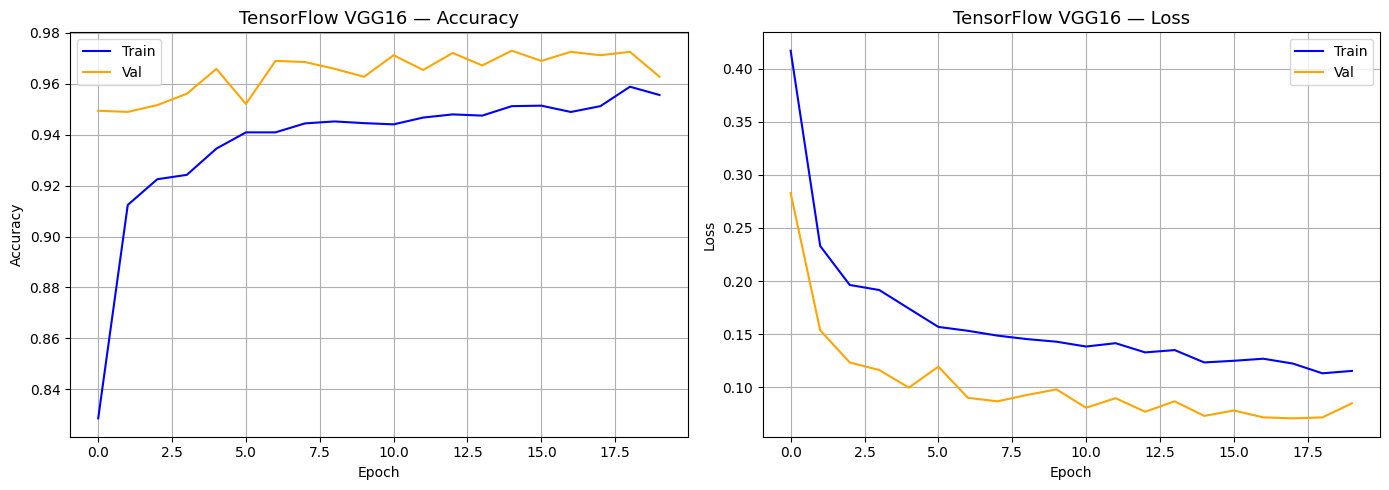

71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.9571 - loss: 0.0928

TensorFlow Test Accuracy : 96.89%
TensorFlow Test Loss     : 0.0718
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step

📊 Classification Report (TensorFlow VGG16):
              precision    recall  f1-score   support

    lung_aca       0.96      0.94      0.95       750
      lung_n       1.00      1.00      1.00       750
    lung_scc       0.95      0.97      0.96       750

    accuracy                           0.97      2250
   macro avg       0.97      0.97      0.97      2250
weighted avg       0.97      0.97      0.97      2250



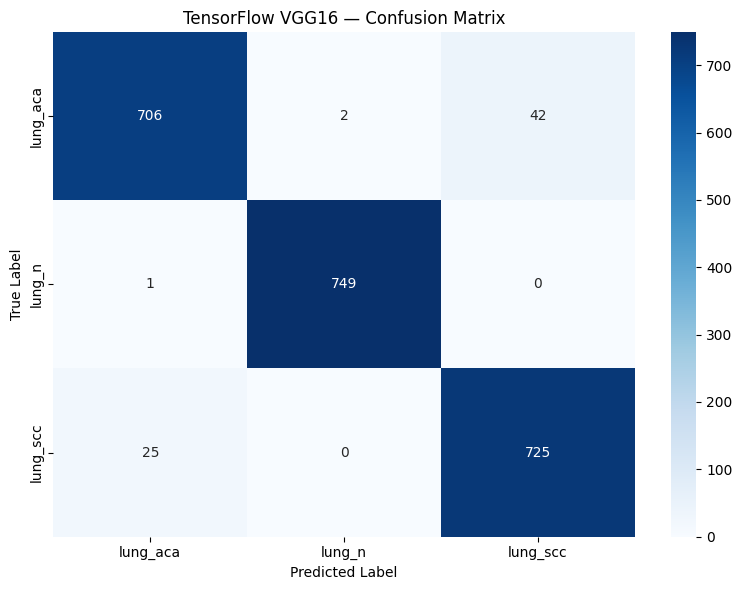

In [15]:
# Plot Accuracy & Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(tf_history.history['accuracy'],     label='Train', color='blue')
axes[0].plot(tf_history.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_title('TensorFlow VGG16 — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(tf_history.history['loss'],     label='Train', color='blue')
axes[1].plot(tf_history.history['val_loss'], label='Val',   color='orange')
axes[1].set_title('TensorFlow VGG16 — Loss', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate
tf_loss, tf_acc = tf_model.evaluate(test_gen)
print(f"\nTensorFlow Test Accuracy : {tf_acc*100:.2f}%")
print(f"TensorFlow Test Loss     : {tf_loss:.4f}")

# Classification Report
y_pred_tf = np.argmax(tf_model.predict(test_gen), axis=1)
y_true    = test_gen.classes

print("\n📊 Classification Report (TensorFlow VGG16):")
print(classification_report(y_true, y_pred_tf, target_names=CLASS_NAMES))

# Confusion Matrix
cm_tf = confusion_matrix(y_true, y_pred_tf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("TensorFlow VGG16 — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Using PyTorch

In [16]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {DEVICE}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder('/content/lung_data/train', transform=train_transform)
val_dataset   = datasets.ImageFolder('/content/lung_data/val',   transform=val_test_transform)
test_dataset  = datasets.ImageFolder('/content/lung_data/test',  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print("PyTorch DataLoaders Ready!")
print(f"   Train  : {len(train_dataset)} images")
print(f"   Val    : {len(val_dataset)} images")
print(f"   Test   : {len(test_dataset)} images")
print(f"   Classes: {train_dataset.class_to_idx}")

Using Device: cuda
✅ PyTorch DataLoaders Ready!
   Train  : 10500 images
   Val    : 2250 images
   Test   : 2250 images
   Classes: {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}


In [18]:
pt_model = torch_models.resnet50(pretrained=True)

# Freeze all pretrained layers
for param in pt_model.parameters():
    param.requires_grad = False

# Replace final fully connected layer
pt_model.fc = nn.Sequential(
    nn.Linear(pt_model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, NUM_CLASSES)
)

pt_model = pt_model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pt_model.fc.parameters(), lr=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=3
)

print("PyTorch ResNet50 Model Ready!")

PyTorch ResNet50 Model Ready!


In [19]:
train_accs, val_accs     = [], []
train_losses, val_losses = [], []
best_val_acc = 0.0
EPOCHS = 20

print("Training PyTorch ResNet50...")

for epoch in range(EPOCHS):
    # Train
    pt_model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = pt_model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # Validate
    pt_model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs  = pt_model(images)
            loss     = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted  = outputs.max(1)
            val_correct  += predicted.eq(labels).sum().item()
            val_total    += labels.size(0)

    val_loss_avg = val_loss / len(val_loader)
    val_acc      = val_correct / val_total
    scheduler.step(val_loss_avg)

    train_accs.append(train_acc);    val_accs.append(val_acc)
    train_losses.append(train_loss); val_losses.append(val_loss_avg)

    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | "
          f"Val Loss: {val_loss_avg:.4f} Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(pt_model.state_dict(),
                   '/content/drive/MyDrive/pt_lung_resnet50.pth')
        print("   Best model saved!")

print("\nPyTorch Training Complete!")

🚀 Training PyTorch ResNet50...
Epoch [01/20] Train Loss: 0.4029 Acc: 86.82% | Val Loss: 0.1698 Acc: 94.18%
   Best model saved!
Epoch [02/20] Train Loss: 0.2221 Acc: 91.89% | Val Loss: 0.1464 Acc: 94.31%
   Best model saved!
Epoch [03/20] Train Loss: 0.1999 Acc: 92.14% | Val Loss: 0.1143 Acc: 95.73%
   Best model saved!
Epoch [04/20] Train Loss: 0.1766 Acc: 93.11% | Val Loss: 0.1124 Acc: 95.29%
Epoch [05/20] Train Loss: 0.1723 Acc: 92.82% | Val Loss: 0.1062 Acc: 95.38%
Epoch [06/20] Train Loss: 0.1627 Acc: 93.47% | Val Loss: 0.1013 Acc: 95.64%
Epoch [07/20] Train Loss: 0.1701 Acc: 93.45% | Val Loss: 0.0994 Acc: 96.04%
   Best model saved!
Epoch [08/20] Train Loss: 0.1681 Acc: 93.57% | Val Loss: 0.0920 Acc: 96.53%
   Best model saved!
Epoch [09/20] Train Loss: 0.1564 Acc: 93.75% | Val Loss: 0.0947 Acc: 96.49%
Epoch [10/20] Train Loss: 0.1472 Acc: 94.14% | Val Loss: 0.0968 Acc: 96.40%
Epoch [11/20] Train Loss: 0.1474 Acc: 93.99% | Val Loss: 0.0884 Acc: 96.13%
Epoch [12/20] Train Loss: 0.

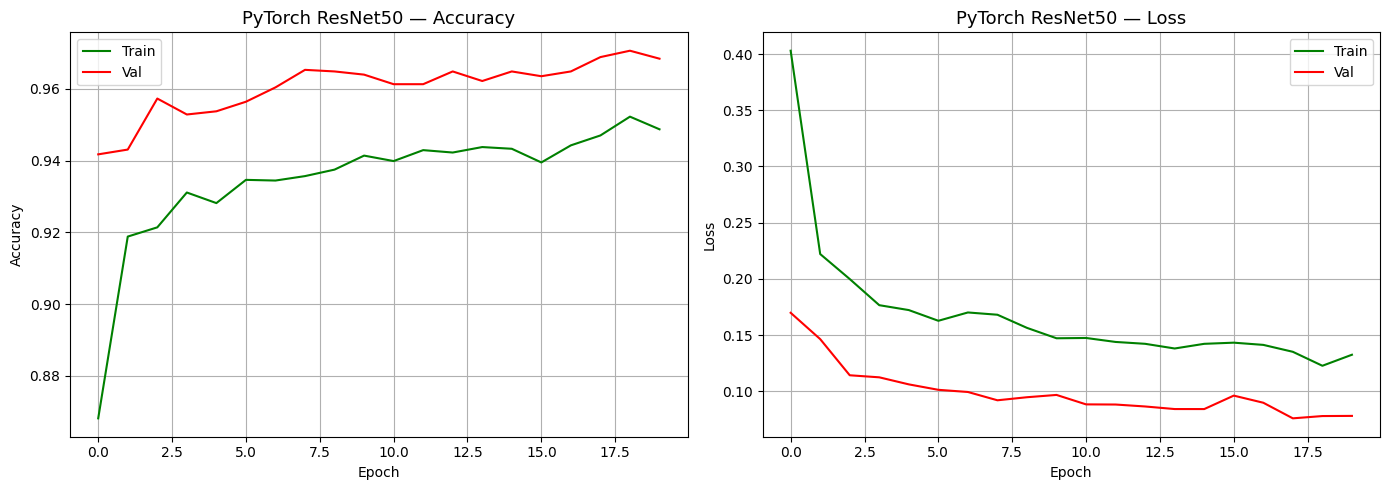


✅ PyTorch Test Accuracy : 96.98%

📊 Classification Report (PyTorch ResNet50):
              precision    recall  f1-score   support

    lung_aca       0.97      0.93      0.95       750
      lung_n       1.00      1.00      1.00       750
    lung_scc       0.94      0.98      0.96       750

    accuracy                           0.97      2250
   macro avg       0.97      0.97      0.97      2250
weighted avg       0.97      0.97      0.97      2250



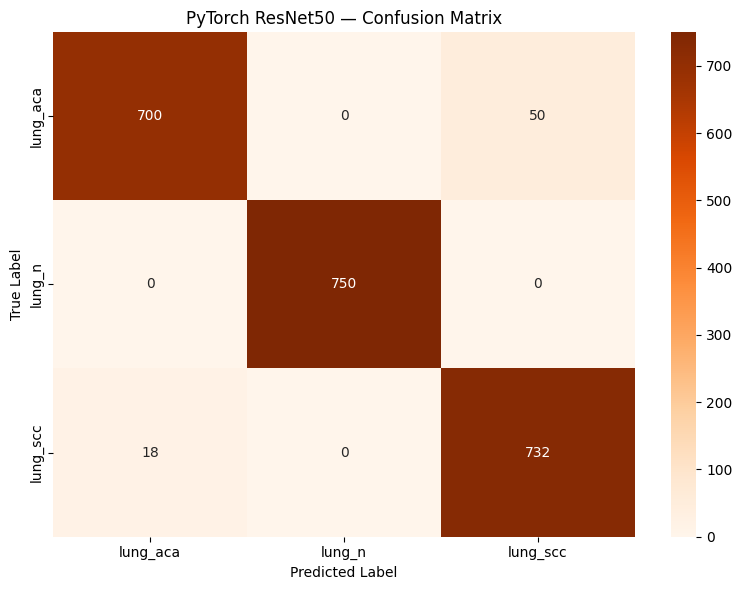

In [20]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_accs, label='Train', color='green')
axes[0].plot(val_accs,   label='Val',   color='red')
axes[0].set_title('PyTorch ResNet50 — Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(train_losses, label='Train', color='green')
axes[1].plot(val_losses,   label='Val',   color='red')
axes[1].set_title('PyTorch ResNet50 — Loss', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

# Evaluate
pt_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images       = images.to(DEVICE)
        outputs      = pt_model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

pt_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"\n✅ PyTorch Test Accuracy : {pt_acc*100:.2f}%")

print("\n📊 Classification Report (PyTorch ResNet50):")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Confusion Matrix
cm_pt = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("PyTorch ResNet50 — Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Final model comparison


        FINAL MODEL COMPARISON
  TensorFlow  VGG16    : 96.89%
  PyTorch     ResNet50 : 96.98%
  Winner: PyTorch ResNet50


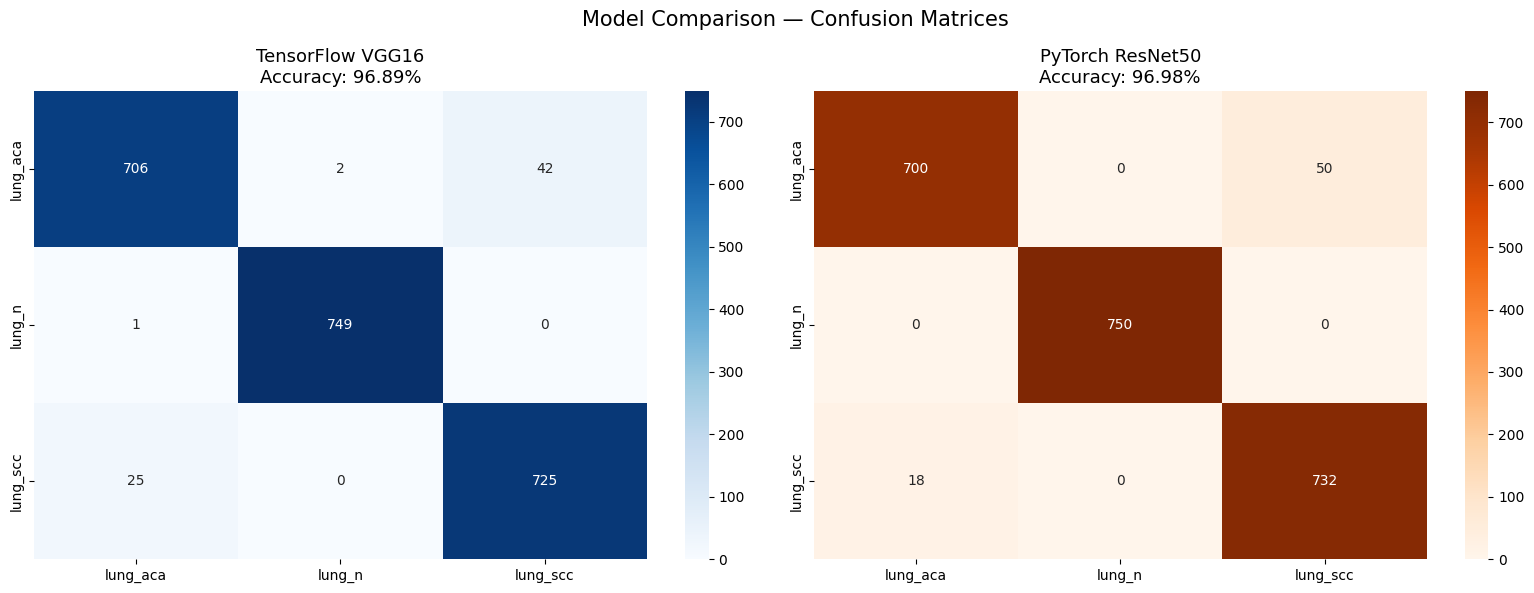

In [21]:
print("\n" + "=" * 50)
print("        FINAL MODEL COMPARISON")
print("=" * 50)
print(f"  TensorFlow  VGG16    : {tf_acc*100:.2f}%")
print(f"  PyTorch     ResNet50 : {pt_acc*100:.2f}%")
print("=" * 50)

winner = "TensorFlow VGG16" if tf_acc > pt_acc else "PyTorch ResNet50"
print(f"  Winner: {winner}")
print("=" * 50)

# Side-by-side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title(f'TensorFlow VGG16\nAccuracy: {tf_acc*100:.2f}%', fontsize=13)

sns.heatmap(cm_pt, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title(f'PyTorch ResNet50\nAccuracy: {pt_acc*100:.2f}%', fontsize=13)

plt.suptitle("Model Comparison — Confusion Matrices", fontsize=15)
plt.tight_layout()
plt.show()